## **Fine-tuning Aya Vision 8B with Unsloth for All Languages (in Afri-Aya Dataset)**

In this notebook, we do LoRA fine-tuning of Aya Vision 8B (official model: CohereLabs/aya-vision-8b) for all languages in our Afri-Aya dataset using unsloth. Follow the instructions and run each cell below.

### Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth 
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.55.4 
!pip install --no-deps trl==0.22.2
!pip install datasets==4.0.0

In [2]:
# Cleanup GPU memory
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

0

In [4]:
from unsloth import FastVisionModel
import torch
import os
from datasets import load_dataset
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

In [ ]:
!hf auth login --token YOUR_HUGGINGFACE_TOKEN_HERE

### Configure, Load Model and Dataset

In [8]:
# Load the Aya Vision model
model, tokenizer = FastVisionModel.from_pretrained(
    "CohereLabs/aya-vision-8b",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

# Configure LoRA for fine-tuning
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=False,
    finetune_mlp_modules=True,
    r=16,  # Increased for multilingual training
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)
print("Loading full Afri-Aya dataset (all languages)...")

# Load the complete dataset (all languages)
dataset = load_dataset("CohereLabsCommunity/afri-aya", split="train")
print(f"Total examples across all languages: {len(dataset)}")

# Show language distribution
from collections import Counter
lang_counts = Counter(dataset["language"])
print("\nSupported Languages:")
for lang, count in sorted(lang_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {lang}: {count} examples")

# Data formatting function
def data_to_chat(ex):
    """
    Convert Afri-Aya dataset format to Unsloth chat format.
    Uses the actual language from the dataset for system prompt.
    """
    q, a = None, None
    language = ex.get("language", "the local language")
    
    # Try to extract first QA pair
    if isinstance(ex.get("qa_pairs"), list) and ex["qa_pairs"]:
        qa0 = ex["qa_pairs"][0] or {}
        q = qa0.get("question_local")
        a = qa0.get("answer_local")
    
    # Fallback to caption if no QA pair found
    if not q or not a:
        q = f"Describe this image in {language}"
        a = ex.get("caption_local", "")
    
    # Skip if still no answer
    if not a:
        return None
    
    # System prompt to encourage native language responses
    sys_text = (
        f"Reply strictly in {language}. "
        f"Use native orthography and natural phrasing. "
        f"Do not translate to English unless explicitly asked."
    )
    
    messages = [
        {"role": "system", "content": [{"type": "text", "text": sys_text}]},
        {"role": "user", "content": [
            {"type": "image"}, 
            {"type": "text", "text": str(q)}
        ]},
        {"role": "assistant", "content": [{"type": "text", "text": str(a)}]},
    ]
    
    return {"messages": messages, "images": [ex["image"]]}

# Apply formatting
print("\nFormatting dataset...")
formatted_dataset = dataset.map(
    data_to_chat,
    remove_columns=dataset.column_names,
    batched=False,
)

# Remove any None entries
formatted_dataset = formatted_dataset.filter(lambda x: x is not None)

print(f"Successfully formatted {len(formatted_dataset)} examples")


/root/miniconda3/lib/python3.13/site-packages/transformers/models/cohere2/configuration_cohere2.py:235: FutureWarning: The `sliding_window_pattern` attribute is deprecated and will be removed in v4.55.0.
  warnings.warn(


==((====))==  Unsloth 2025.9.11: Fast Aya_Vision patching. Transformers: 4.55.4.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 4. Max memory: 39.394 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 4/4 [00:10<00:00,  2.60s/it]


Unsloth: Making `base_model.model.model.vision_tower.vision_model` require gradients
Loading full Afri-Aya dataset (all languages)...
Total examples across all languages: 2466

Supported Languages:
  Kinyarwanda: 409 examples
  Luganda (Ganda): 388 examples
  Twi: 279 examples
  Nyankore: 241 examples
  Hausa: 208 examples
  Egyptian Arabic: 207 examples
  Yoruba: 186 examples
  Kirundi: 183 examples
  Zulu: 161 examples
  Krio: 75 examples
  Gishu: 70 examples
  Igbo: 48 examples
  Swahili: 11 examples

Formatting dataset...
Successfully formatted 2466 examples


### Train Model (for all langauges)

In [9]:
FastVisionModel.for_training(model) # Enable training mode

# Create trainer
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(
        model, 
        tokenizer, 
        resize=(336, 336)
    ),
    train_dataset=formatted_dataset,
    args=SFTConfig(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        warmup_steps=50,
        num_train_epochs=1,  # Full epoch through all data
        learning_rate=1e-4,  # Lower LR for stability
        logging_steps=10,
        optim="paged_adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",  # Cosine for full training
        seed=3407,
        output_dir="outputs_multilingual",
        save_strategy="steps",
        save_steps=500,
        report_to="none",
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_length=2048,
        fp16=False,
        bf16=True,
    ),
)

print("\nStarting multilingual training...")
print(f"Training on {len(formatted_dataset)} examples")
print(f"Estimated steps: ~{len(formatted_dataset) // 4}")

# Train the model
trainer_stats = trainer.train()

print("\nTraining complete!")
print(f"Model checkpoints saved to: outputs_multilingual/")

# Save the final model
model.save_pretrained("lora_model_multilingual")
tokenizer.save_pretrained("lora_model_multilingual")

print(f"Final LoRA adapter saved to: lora_model_multilingual/")
print("\nTraining statistics:")
print(f"  Final loss: {trainer_stats.training_loss:.4f}")
print(f"  Total steps: {trainer_stats.global_step}")


Starting multilingual training...
Training on 2466 examples
Estimated steps: ~616


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,466 | Num Epochs = 1 | Total steps = 617
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 33,025,536 of 8,664,867,568 (0.38% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,15.432900
20,13.587800
30,9.843700
40,5.904200
50,2.772400
60,1.523200
70,1.073100
80,0.935000
90,0.915400
100,0.964400


/root/miniconda3/lib/python3.13/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Training complete!
Model checkpoints saved to: outputs_multilingual/
Final LoRA adapter saved to: lora_model_multilingual/

Training statistics:
  Final loss: 1.4007
  Total steps: 617


In [2]:
# Cleanup GPU memory
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

0

### Inference Trained Model

/root/miniconda3/lib/python3.13/site-packages/transformers/models/cohere2/configuration_cohere2.py:235: FutureWarning: The `sliding_window_pattern` attribute is deprecated and will be removed in v4.55.0.
  warnings.warn(


==((====))==  Unsloth 2025.9.11: Fast Aya_Vision patching. Transformers: 4.55.4.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 4. Max memory: 39.394 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 4/4 [00:11<00:00,  2.84s/it]


Testing multilingual model...


Language: Krio


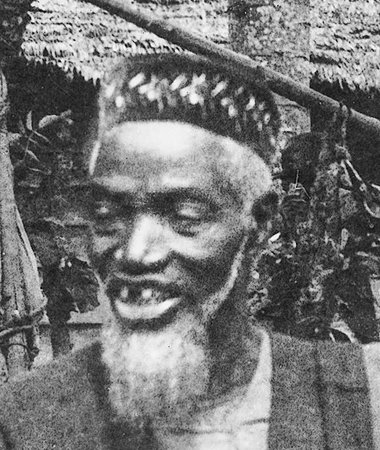


Question: Wetin dis pikchɔ de sho?
Response: Dis picshɔ dɛn fɔr wɔt pikin we dey jut 'Abubakar Karamej'.


Language: Egyptian Arabic


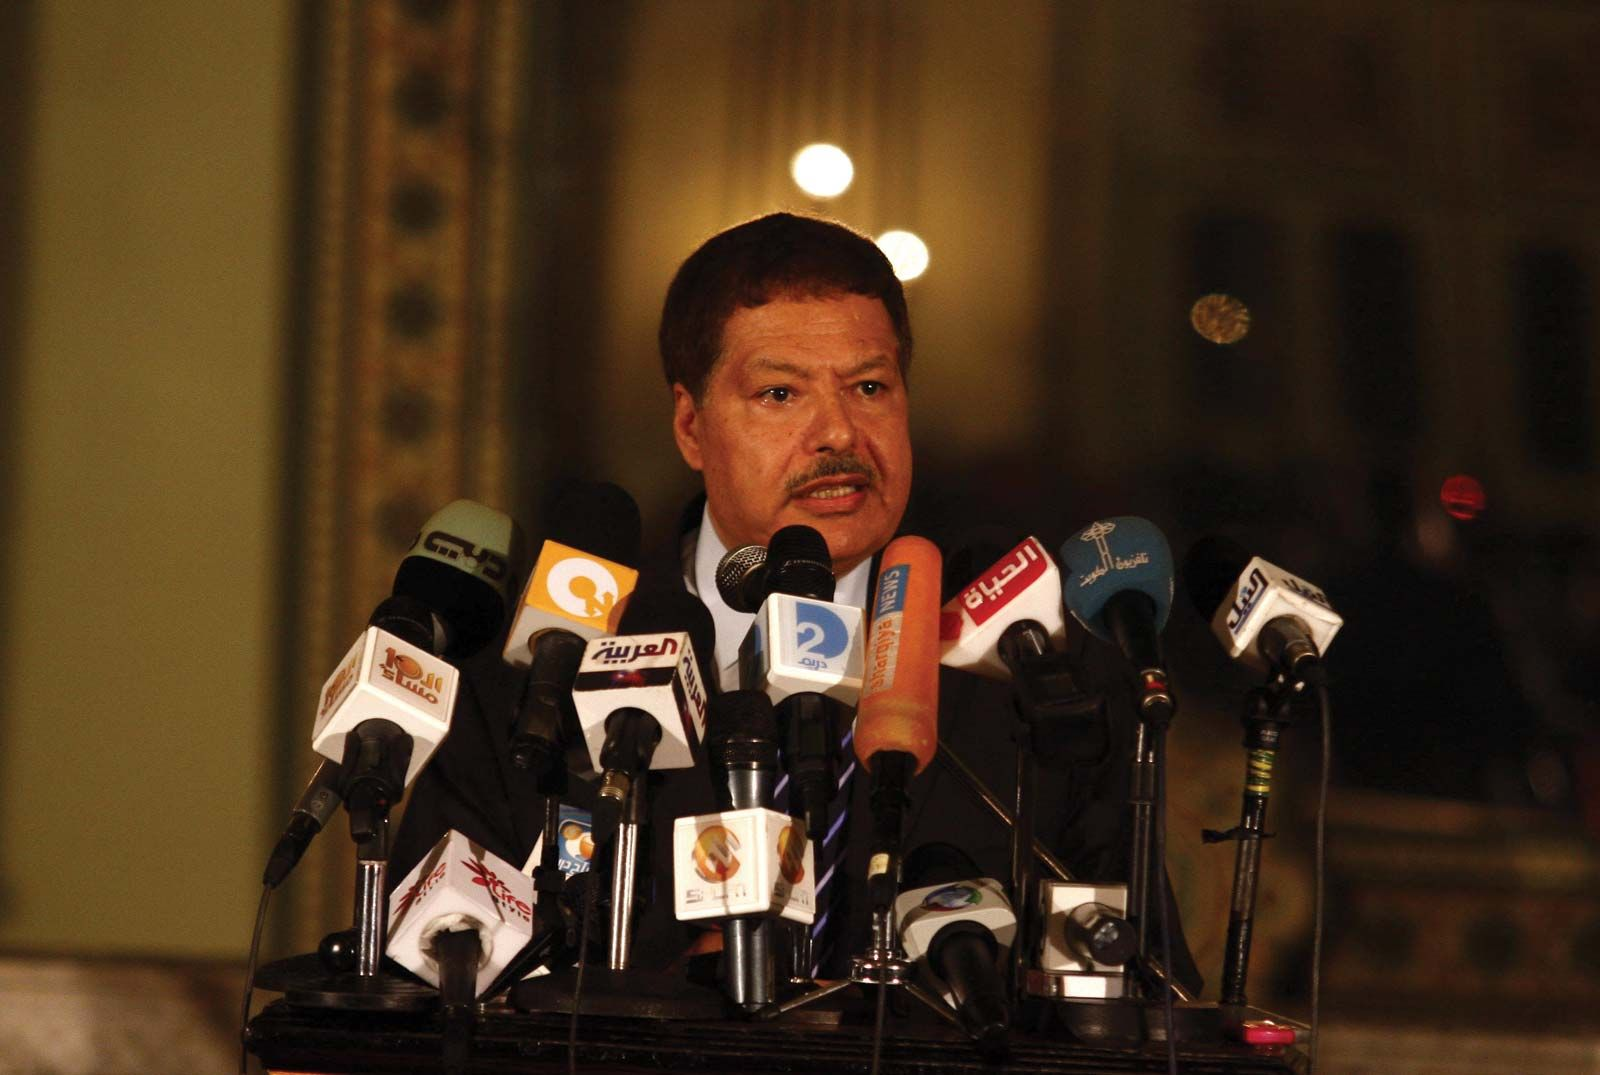

/root/miniconda3/lib/python3.13/site-packages/transformers/models/cohere2/configuration_cohere2.py:235: FutureWarning: The `sliding_window_pattern` attribute is deprecated and will be removed in v4.55.0.
  warnings.warn(



Question: الصورة دي بتوضح إيه؟
Response: الصورة تصور رجلًا يقف أمام مجموعة من الميكروفونات في مؤتمر صحفي أو بيان عام، وهو يتحدث إلى وسائل الإعلام المختلفة التي تجمعت للاستماع إليه والتحقيق معه حول موضوع معين. يظهر الرجل مرتدياً ملابس رسمية ووقفته توحي بالثقة أثناء تحدثه للصحافة. وجود العديد من الماكينات يشير إلى أهمية الحدث وأهميته بالنسبة له وللجمهور الذي


Language: Yoruba


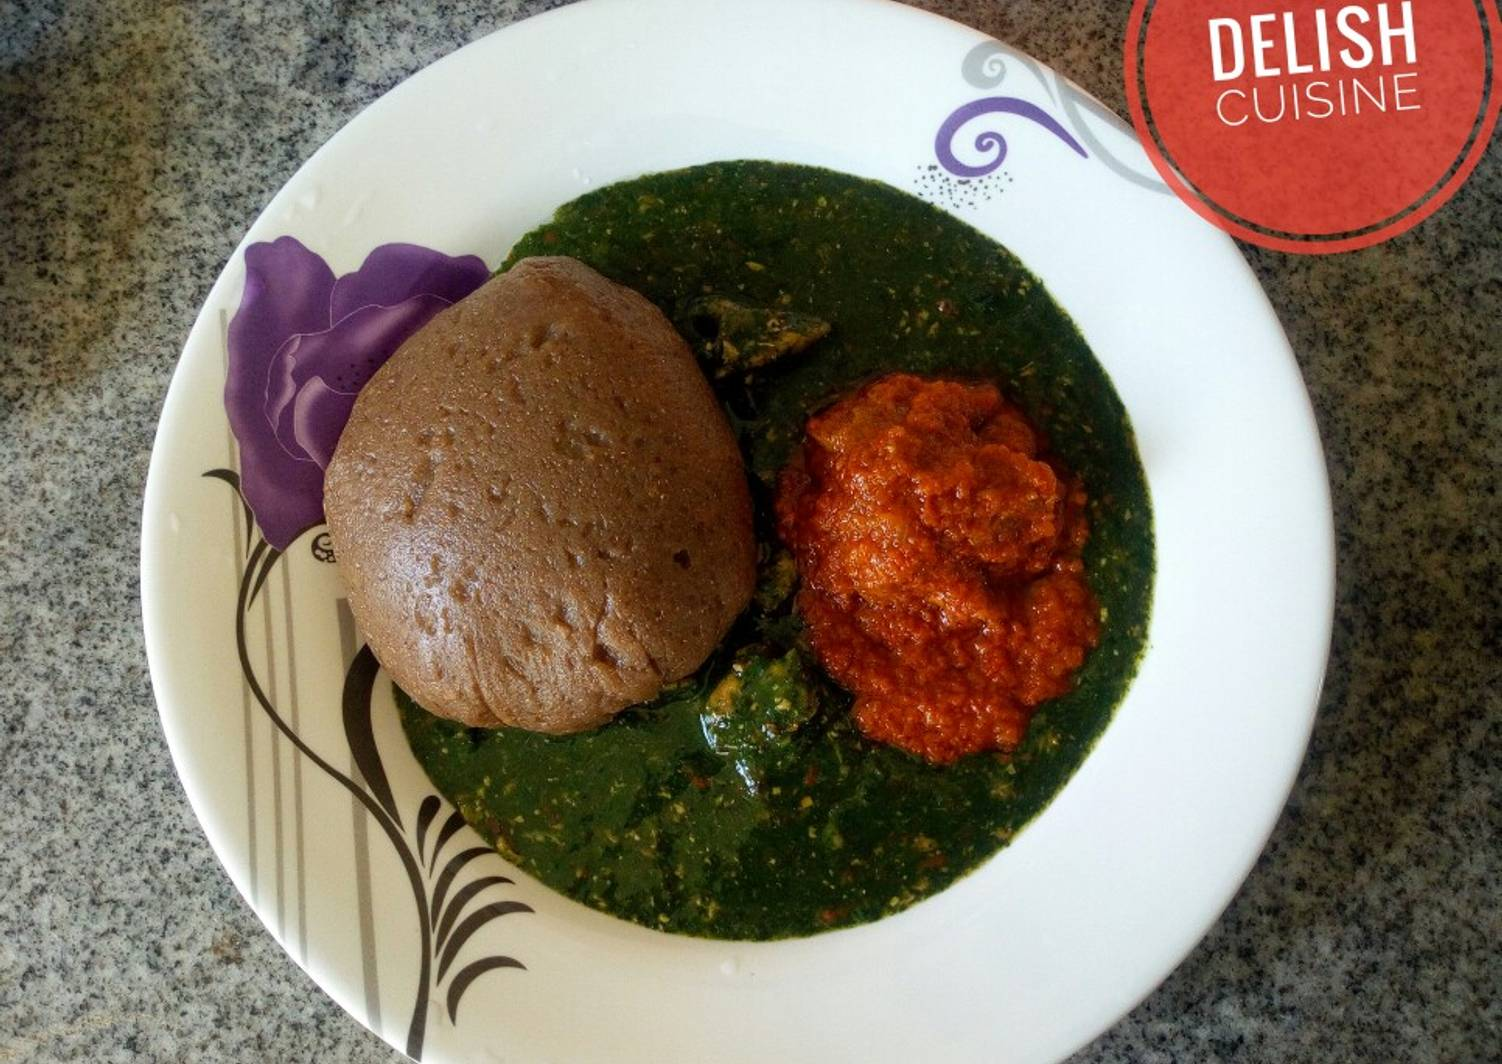


Question: Kini aworan yi n ṣe afihan?
Response: Aṣọfẹ́ jutejú ti o ni ìbílẹ̀ Yorùbá tí wọn sì gbàgbajá fún àwọn ènìyàn pàtàkò nípa lédé náà máa gbé kí 'afihán' tuntun mímọ́ tó bùgbí ati ó láti dára bí ewérèsè. Aṣọpá juteji sí ay


Language: Luganda (Ganda)


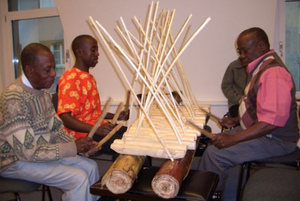


Question: Ekifaananyi kino kiraga ki?
Response: Ekifanaanini yezithombe zomculo eziyimbi ezizwe njengesitshozweni esikhathi seNingxoxa sakho sisebenza ngokuthi 'ekifaanayi'. Ekifaanayini yokuhlonipha imihlanganiso eyenzeka emlandleko wamandla wezintaba zamasiko zasemizi futhi zihambisana namelani omlando wakhe el

Inferencing complete!


In [7]:
model, tokenizer = FastVisionModel.from_pretrained(
    "outputs_multilingual/checkpoint-617",
    load_in_4bit=True,
)

FastVisionModel.for_inference(model)

# Load dataset
dataset = load_dataset("CohereLabsCommunity/afri-aya", split="train")

# Define test cases: language and custom question
test_cases = [
    {
        "language": "Krio",
        "question": "Wetin dis pikchɔ de sho?"  # What does this picture show?
    },
    {
        "language": "Egyptian Arabic",
        "question": "الصورة دي بتوضح إيه؟"  # What does this picture show?
    },
    {
        "language": "Yoruba",
        "question": "Kini aworan yi n ṣe afihan?"  # What is this image showing?
    },
    {
        "language": "Luganda (Ganda)",
        "question": "Ekifaananyi kino kiraga ki?"  # What does this image show?
    },
]

print("Testing multilingual model...\n")

for test in test_cases:
    lang = test["language"]
    question = test["question"]
    
    # Get first image for this language
    lang_data = dataset.filter(lambda x: x["language"] == lang)
    if len(lang_data) == 0:
        print(f"No data found for {lang}\n")
        continue
    
    image = lang_data[0]["image"]
    
    # Display the image
    print(f"\n{'='*70}")
    print(f"Language: {lang}")
    print(f"{'='*70}")
    image.show()
    
    # Create prompt
    messages = [
        # {"role": "system", "content": [{"type": "text", "text": f"Reply strictly in {lang}."}]}, # use to boost response in your language
        {"role": "user", "content": [
            {"type": "image"}, 
            {"type": "text", "text": question}
        ]}
    ]
    
    # Generate
    input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(image, input_text, return_tensors="pt").to("cuda")
    
    outputs = model.generate(
        **inputs, 
        max_new_tokens=100,
        temperature=0.7,
        top_p=0.9, 
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        use_cache=True,
    )
    
    # Decode only new tokens
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    
    print(f"\nQuestion: {question}")
    print(f"Response: {response}")
    print(f"{'='*70}\n")

print(f"Inferencing complete!")

### Push Model to Hub

In [ ]:
from unsloth import FastVisionModel
model, tokenizer = FastVisionModel.from_pretrained(
    "outputs_Krio/checkpoint-190",  # use either your adapter folder or a specific checkpoint: e.g lora_model_Krio or outputs_Krio/checkpoint-190
    load_in_4bit=True,
)
model.push_to_hub_merged("YOUR_USERNAME/afri-aya-vision-8b", tokenizer, token = "YOUR_HF_TOKEN")